# <font color= 'aqua'>Imports</font>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import  RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix

# <font color= 'aqua'> Load Dataset </font>

In [ ]:
titanic_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Csv_file/titanic.csv')
titanic_raw.keys()

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

# <font color= 'aqua'> Remove unnecessary columns </font>

In [ ]:
titanic = titanic_raw.drop(columns= ['PassengerId', 'Name', 'Ticket', 'Cabin'])
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


# <font color= 'aqua'> Feature Engineering </font>

In [ ]:
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1
titanic['FamilySize'].value_counts()

,count
FamilySize,
1,537
2,161
3,102
4,29
6,22
5,15
7,12
11,7
8,6


In [ ]:
titanic['isAlone'] = (titanic['FamilySize'] == 1).astype(int)
titanic['isAlone'].value_counts()

,count
isAlone,
1,537
0,354


In [ ]:
titanic['MotherChild'] = ((titanic['Sex'] == 'female') & (titanic['Parch'] > 0)).astype(int)
titanic['MotherChild'].value_counts()

,count
MotherChild,
0,771
1,120


<Axes: xlabel='FamilySize', ylabel='Survived'>

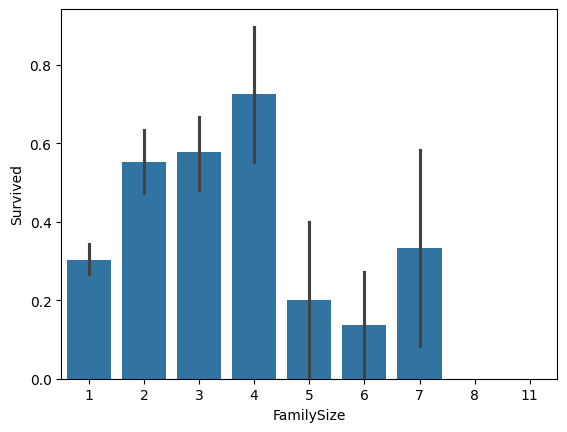

In [ ]:
sns.barplot(x='FamilySize', y='Survived', data=titanic)

<Axes: xlabel='isAlone', ylabel='Survived'>

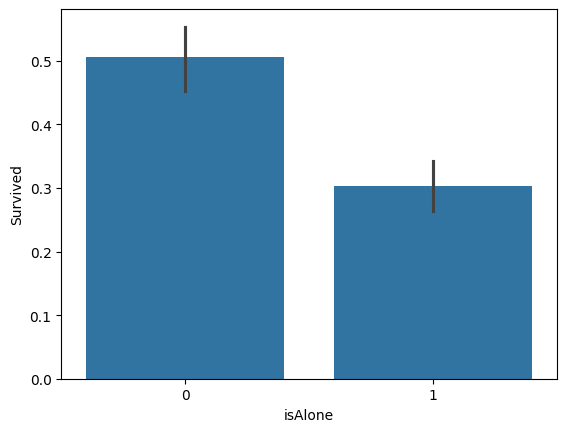

In [ ]:
sns.barplot(x='isAlone', y='Survived', data=titanic)

<Axes: xlabel='MotherChild', ylabel='Survived'>

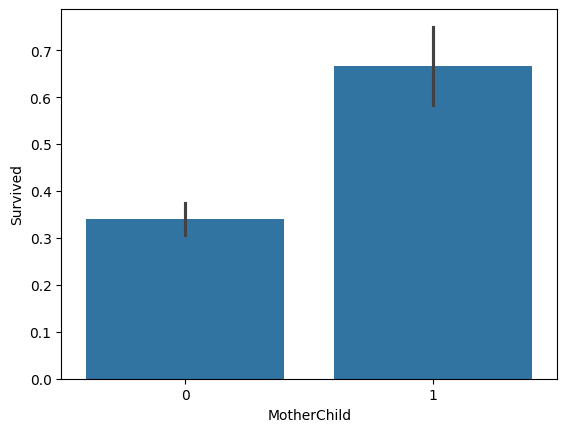

In [ ]:
sns.barplot(x='MotherChild', y='Survived', data=titanic)

<Axes: xlabel='Sex', ylabel='Survived'>

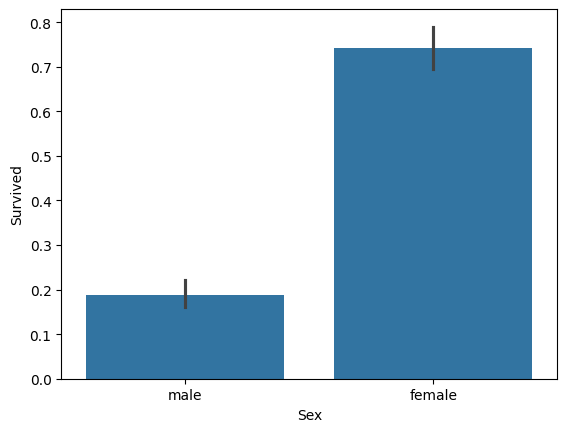

In [ ]:
sns.barplot(x='Sex', y='Survived', data=titanic)

# <font color= 'aqua'> Handle Missing Values </font>

In [ ]:
titanic_df = pd.DataFrame(titanic)
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2
FamilySize,0
isAlone,0


In [ ]:
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
FamilySize,0
isAlone,0


# <font color= 'aqua'> Define Input and Target </font>

In [ ]:
input = titanic_df.drop(columns= ['Survived'])
target = titanic_df['Survived']

# <font color= 'aqua'> Train Test Split </font>

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(input, target, test_size=0.2, random_state=42)

# <font color= 'aqua'> Preprocessing Pipeline </font>

In [ ]:
process = ColumnTransformer(
    transformers=[
        ('Encoder', OneHotEncoder(drop='first', sparse_output=False), ['Sex', 'Embarked'])
    ],
    remainder='passthrough',
    force_int_remainder_cols=False
)

# <font color= 'aqua'> Pipeline </font>

In [ ]:
pl = Pipeline([
    ('processing', process),
    ('model', RandomForestClassifier(random_state=42))
])

# <font color= 'aqua'> Grid Search </font>

In [ ]:
param_grid = {
    'model__n_estimators': [100,200,300],
    'model__max_depth': [None,5,10],
    'model__min_samples_split': [2,5,10]
}

grid = GridSearchCV(
    pl,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, Y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('processing',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('Encoder',
                                                                         OneHotEncoder(drop='first',
                                                                                       sparse_output=False),
                                                                         ['Sex',
                                                                          'Embarked'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200, 300]},
             scoring='accuracy')

# <font color= 'aqua'> Best Parameters </font>

In [ ]:
print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best parameters: {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV score: 0.8356249384418397


# <font color= 'aqua'> Use Best Model </font>

In [ ]:
best_model = grid.best_estimator_

score = best_model.score(X_test, Y_test)

print("Test Accuracy:", score)

Test Accuracy: 0.8044692737430168


# <font color= 'aqua'> Confusion Matrix </font>

Text(0.5, 1.0, 'Confusion Matrix')

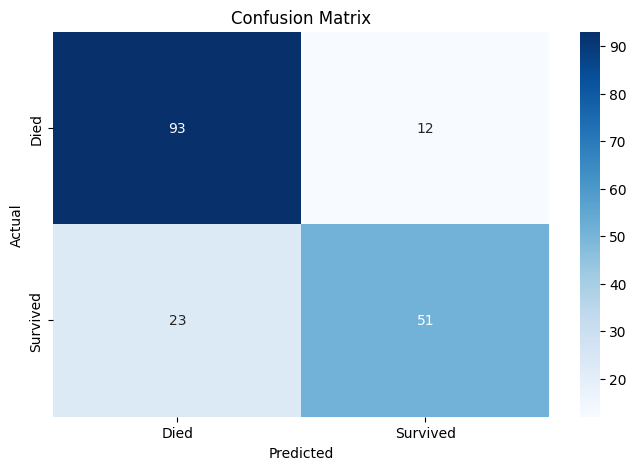

In [ ]:
Y_pred = best_model.predict(X_test)

cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(8,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Died','Survived'],
    yticklabels=['Died','Survived']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# <font color= 'aqua'> Feature Importance </font>

In [ ]:
feature_names = best_model.named_steps['processing'].get_feature_names_out()

model = best_model.named_steps['model']

for name, score in zip(feature_names, model.feature_importances_):
    print(name, score)

Encoder__Sex_male 0.4182405137211969
Encoder__Embarked_Q 0.007488800316575085
Encoder__Embarked_S 0.019595901173436195
remainder__Pclass 0.13371890196124944
remainder__Age 0.09528020626413457
remainder__SibSp 0.031552588689963655
remainder__Parch 0.022275082619601944
remainder__Fare 0.1649692028224436
remainder__FamilySize 0.058847623507016236
remainder__isAlone 0.010137918912530653
remainder__MotherChild 0.03789326001185166


# <font color= 'aqua'> Test Data </font>

In [ ]:
test_data = pd.DataFrame({
    'Pclass':[3,1,3],
    'Sex':['male','female','male'],
    'Age':[22,35,30],
    'SibSp':[1,0,0],
    'Parch':[0,0,0],
    'Fare':[7.25,80,8],
    'Embarked':['S','C','Q'],
    'FamilySize':[2,1,1],
    'isAlone': [0, 1, 1],
    'MotherChild': [1, 0, 1]
})

# <font color= 'aqua'> Testing </font>

In [ ]:
best_model.predict(test_data)

array([0, 1, 0])

In [ ]:
best_model.predict_proba(test_data)

array([[0.70820215, 0.29179785],
       [0.07031314, 0.92968686],
       [0.79538146, 0.20461854]])